In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

Loading and knowing the Dataset

In [2]:
# reading the csv file for the bank data. 
bank_data = pd.read_csv('Bank_Churn.csv')

# get the num of rows and column in our dataset
bank_data.shape  # 1000 rows and 13 column. 

# getting the info about the data 
bank_data.info() # no missing values in our dataset & datatype is alsso clean. 

# checking the content of the first few rows of our data 
bank_data.head() 

# more info about our data 
bank_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Performing EDA

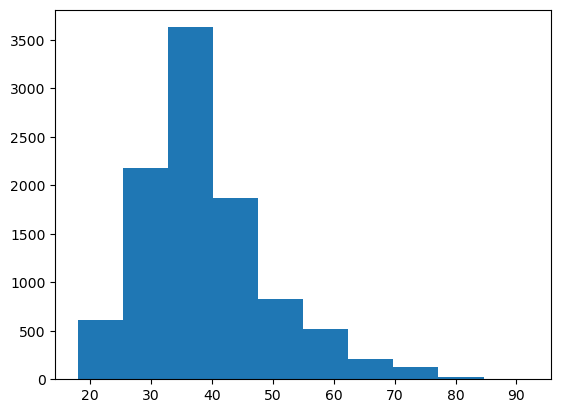

In [3]:
# bank_data.drop(columns=['Surname', 'CustomerId'], inplace=True)
# print(bank_data.columns.to_list())

# Analyzing Age
age = bank_data['Age']
age.min() # 18
age.max() # 92
plt.hist(age)
plt.show()

# a lot of bank customers fall under the age of 35-45


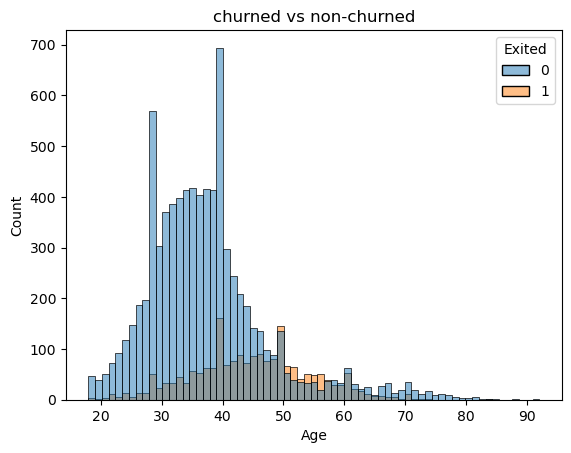

In [4]:
sns.histplot(data=bank_data, x='Age', hue='Exited')
plt.title('churned vs non-churned')
plt.show()
## graph shows that people around the age of 18-49 had lesser people that churned than those who churned. 
## also, people around the age >= 50 and < 67 churned more than people who stayed. 

Average age of churners and non-churners. 

In [5]:
bank_data.groupby('Exited')['Age'].mean()
## atribute 1: higher age is common among churners.

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

Exploring Balance vs Exited

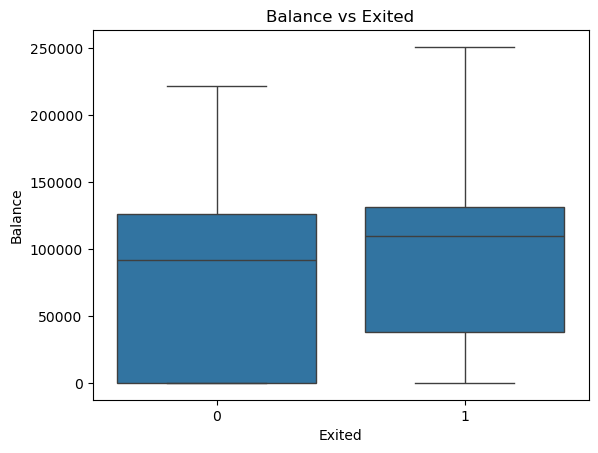

In [6]:
# checking Balance 
sns.boxplot(data=bank_data, x='Exited', y='Balance')
plt.title('Balance vs Exited')
plt.show()

# non-churers have low balance than churners. 

Average balance of churners and non-churners. 

In [7]:
bank_data.groupby('Exited')['Balance'].mean() 
# attribute 2: churners have high balance than non-churners. 

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

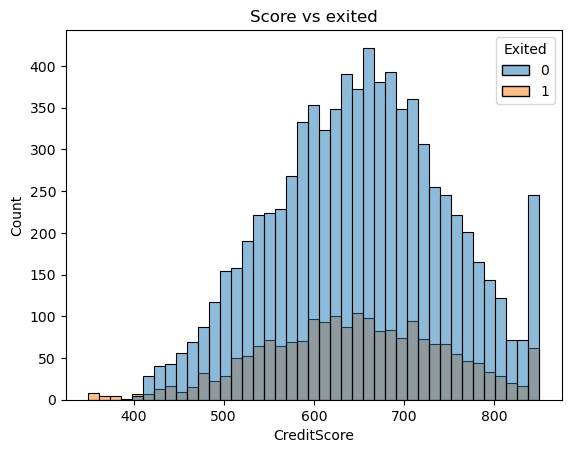

In [8]:
sns.histplot(data=bank_data, x='CreditScore', hue='Exited')
plt.title('Score vs exited')
plt.show()


Average score for churners and non-churners. 

In [9]:
bank_data.groupby('Exited')['CreditScore'].mean()
## low creditscore for churners .

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

Geography 

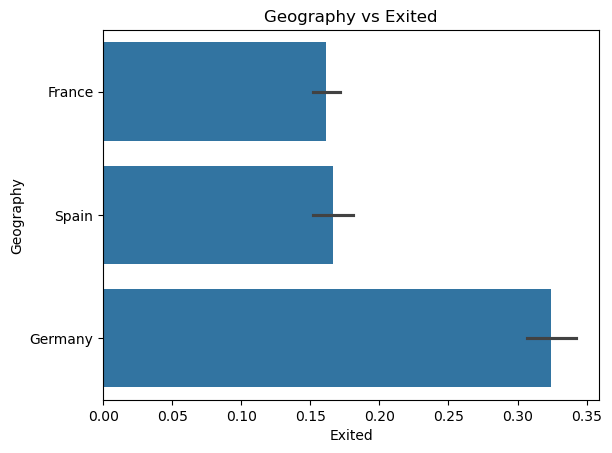

In [10]:
sns.barplot(data=bank_data, x='Exited', y='Geography')
plt.title('Geography vs Exited')
plt.show()

In [11]:
bank_data.groupby('Geography')['Exited'].mean()
# churners are populated in germany. 

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [12]:
bank_data.groupby('Geography')[['Balance', 'Age']].mean()
# 

,Balance,Age
Geography,,
France,62092.636516,38.511767
Germany,119730.116134,39.771622
Spain,61818.147763,38.890997


Gender

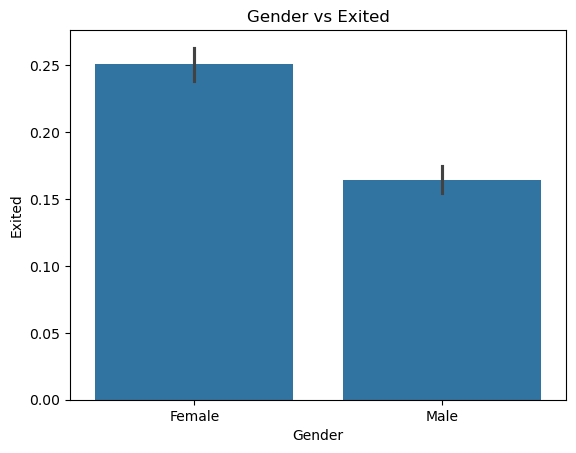

In [13]:
sns.barplot(data=bank_data, x='Gender', y='Exited')
plt.title("Gender vs Exited")
plt.show()

In [14]:
bank_data.groupby('Gender')['Exited'].mean()
# females are more likely more likely to churn than males. 

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [15]:
bank_data.groupby('Gender')[['Balance', 'Age']].mean()

,Balance,Age
Gender,,
Female,75659.369139,39.238389
Male,77173.974506,38.658237


Estimated Salary. 

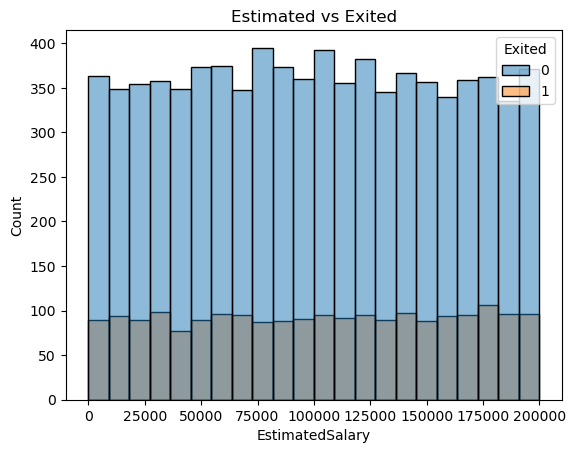

In [16]:
sns.histplot(data=bank_data, x='EstimatedSalary', hue='Exited')
plt.title('Estimated vs Exited')
plt.show()

In [17]:
bank_data.groupby('Exited')['EstimatedSalary'].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

In [18]:
bank_data.groupby('Exited')['EstimatedSalary'].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,99738.391772,57405.586966,90.07,50783.49,99645.04,148609.955,199992.48
1,2037.0,101465.677531,57912.418071,11.58,51907.72,102460.84,152422.910,199808.10


<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

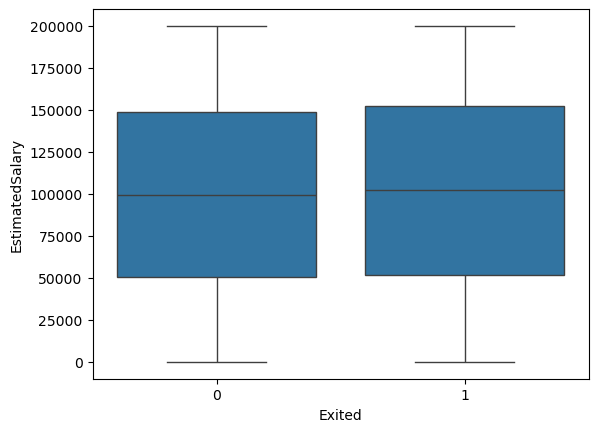

In [19]:
sns.boxplot(data=bank_data, x='Exited', y='EstimatedSalary')

Ignore for now. 

Estimated Salary

In [20]:
# Check skewness of EstimatedSalary
print("Overall skewness:", bank_data['EstimatedSalary'].skew())
print("Skewness by Exited:")
bank_data.groupby('Exited')['EstimatedSalary'].skew()

Overall skewness: 0.002085357661558513
Skewness by Exited:


Exited
0    0.010996
1   -0.033104
Name: EstimatedSalary, dtype: float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\1864045116.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bank_data.groupby(pd.cut(bank_data['EstimatedSalary'], bins=20))['Exited']\


Exited
0    Axes(0.1,0.15;0.8x0.75)
1    Axes(0.1,0.15;0.8x0.75)
Name: EstimatedSalary, dtype: object

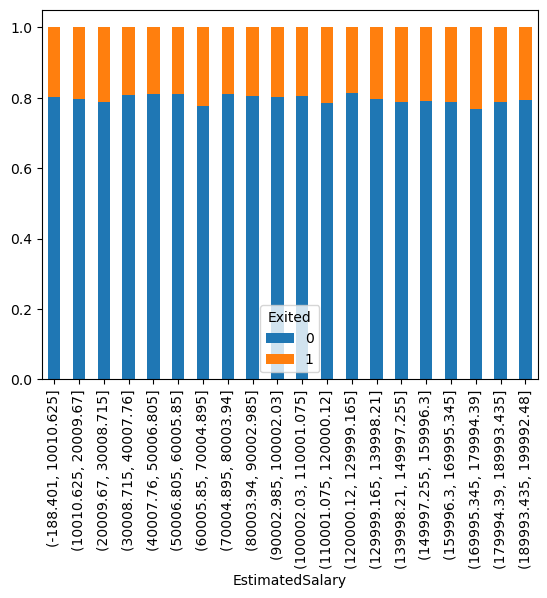

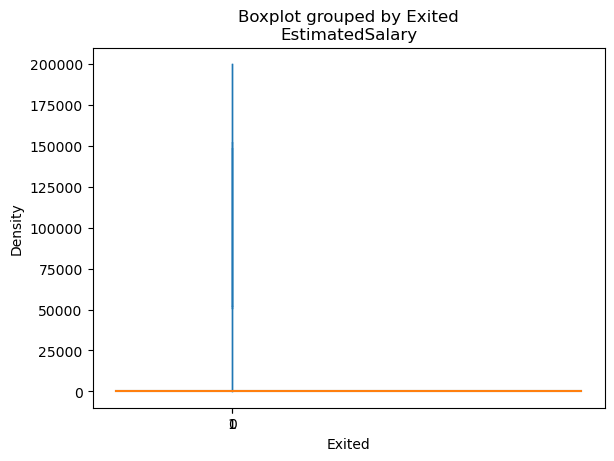

In [21]:
# Option 1: Normalized stacked bar (proportions instead of counts)
bank_data.groupby(pd.cut(bank_data['EstimatedSalary'], bins=20))['Exited']\
  .value_counts(normalize=True)\
  .unstack()\
  .plot(kind='bar', stacked=True)

# Option 2: Box plot - directly compares salary distribution by churn
bank_data.boxplot(column='EstimatedSalary', by='Exited')

# Option 3: KDE plot
bank_data.groupby('Exited')['EstimatedSalary'].plot(kind='kde')

Tenure

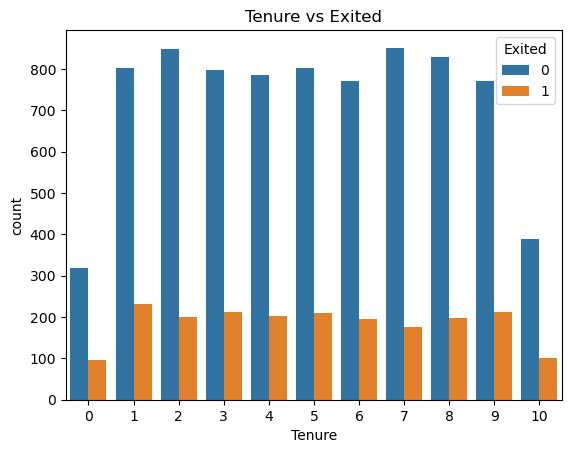

In [22]:
sns.countplot(data=bank_data, x='Tenure', hue='Exited')
plt.title('Tenure vs Exited')
plt.show()

In [23]:
bank_data.groupby('Exited')['Tenure'].mean()
# Churn rate is not strongly affected by Tenure. 

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

NumOfProducts

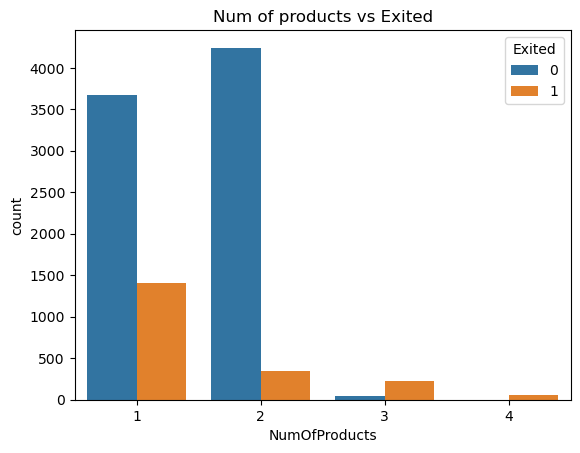

In [24]:
sns.countplot(data=bank_data, x='NumOfProducts', hue='Exited')
plt.title('Num of products vs Exited')
plt.show()

In [25]:
bank_data.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [26]:
bank_data.groupby('Exited')['NumOfProducts'].count()

Exited
0    7963
1    2037
Name: NumOfProducts, dtype: int64

IS Active Member

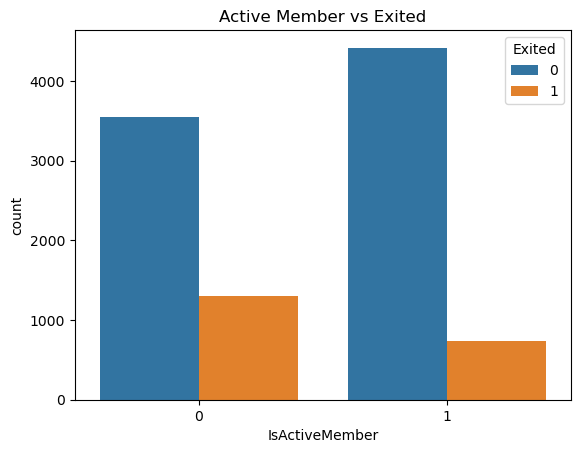

In [27]:
sns.countplot(data=bank_data, x='IsActiveMember', hue='Exited')
plt.title('Active Member vs Exited')
plt.show()

In [28]:
bank_data.groupby('Exited')['IsActiveMember'].mean()

Exited
0    0.554565
1    0.360825
Name: IsActiveMember, dtype: float64

Has Credit card. 

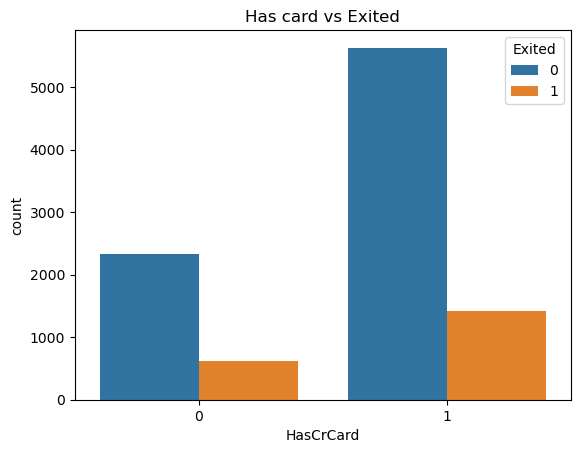

In [29]:
sns.countplot(data=bank_data, x='HasCrCard', hue='Exited')
plt.title("Has card vs Exited")
plt.show()

In [30]:
bank_data.groupby('Exited')['HasCrCard'].mean()

Exited
0    0.707146
1    0.699067
Name: HasCrCard, dtype: float64

Correlation between different Datas that strengthen our analysis. 

Age, Gender, Balance, Geography are the reasonable data for this analysis. 

Age and Gender

C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\3075061091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aged = bank_data.groupby(['Gender', pd.cut(bank_data['Age'], bins=[18,35,50,65,92])])['Exited'].mean().reset_index()


   Gender       Age    Exited
0  Female  (18, 35]  0.111050
1  Female  (35, 50]  0.292833
2  Female  (50, 65]  0.613636
3  Female  (65, 92]  0.183333
4    Male  (18, 35]  0.061659
5    Male  (35, 50]  0.205728
6    Male  (50, 65]  0.450292
7    Male  (65, 92]  0.090278


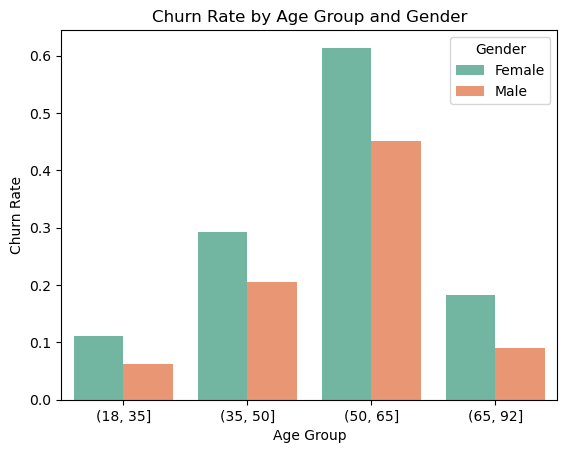

In [31]:
## Gender and Geography
aged = bank_data.groupby(['Gender', pd.cut(bank_data['Age'], bins=[18,35,50,65,92])])['Exited'].mean().reset_index()
print(aged)
sns.barplot(data=aged, x='Age', y='Exited', hue='Gender', palette='Set2')
plt.title('Churn Rate by Age Group and Gender')
plt.ylabel('Churn Rate')
plt.xlabel('Age Group')
plt.show()

# for females, churn rate is high among people aged (50 - 65) = 61%
# Females churned more than male in all age category. 

Gender and Geography

   Gender Geography    Exited
0  Female    France  0.203450
1  Female   Germany  0.375524
2  Female     Spain  0.212121
3    Male    France  0.127134
4    Male   Germany  0.278116
5    Male     Spain  0.131124


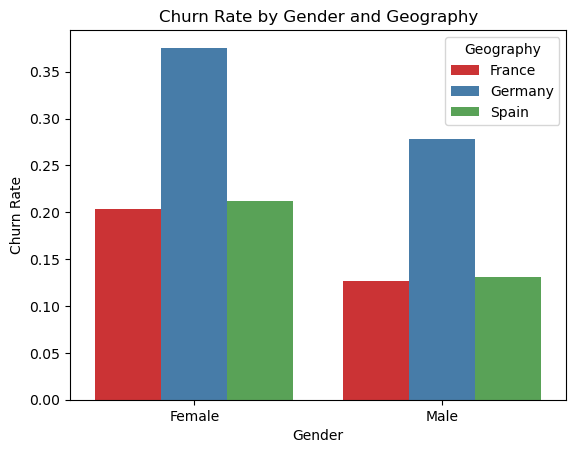

In [32]:
geo = bank_data.groupby(['Gender', 'Geography'])['Exited'].mean().reset_index()
print(geo)
sns.barplot(data=geo, x='Gender', y='Exited', hue='Geography', palette='Set1')
plt.title('Churn Rate by Gender and Geography')
plt.ylabel('Churn Rate') 
plt.xlabel('Gender')
plt.show()

# churn rate is high in germany for both females and male. 

Balance and Geography 

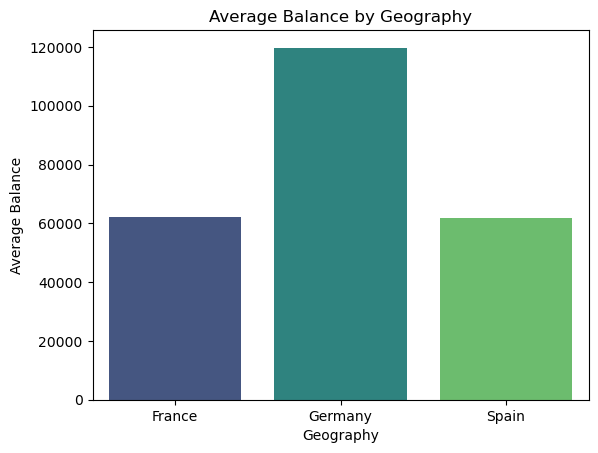

In [33]:
bal = bank_data.groupby('Geography')['Balance'].mean().reset_index()

sns.barplot(data=bal, x='Geography', y='Balance', hue='Geography', palette='viridis')
plt.title('Average Balance by Geography')
plt.ylabel('Average Balance')
plt.xlabel('Geography')
plt.show()\

## Churners are locted in germany and they have very high balance. 

Age and Balance

Age_group  Exited
18-35      0         72433.383481
           1         94115.118000
36-50      0         73170.547343
           1         90948.574206
51-65      0         73712.535864
           1         89807.842879
66-92      0         68245.306376
           1         91451.278571
Name: Balance, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\777810431.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(bank_data.groupby(['Age_group', 'Exited'])['Balance'].mean())


<Axes: xlabel='Age_group', ylabel='Balance'>

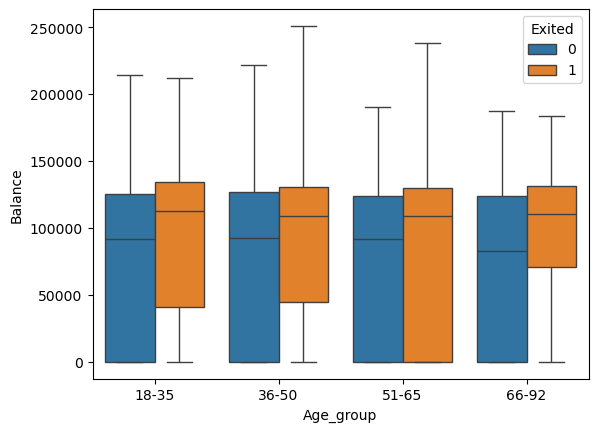

In [34]:
bank_data['Age_group'] = pd.cut(bank_data['Age'], bins=[18,35,50,65,92], labels=['18-35','36-50','51-65','66-92'])
print(bank_data.groupby(['Age_group', 'Exited'])['Balance'].mean())
sns.boxplot(data=bank_data, x='Age_group', y='Balance', hue='Exited')
## In every of the age bracket, the churners have high percentage than the non-churners. 